### Pandas DataFrames: Advanced Data Cleaning and Analysis
In this lesson, we explored the following pandas topics:

**1.Customizable Imputation of Missing Values:**
*   **1-1.Imputing with Mean/Median/Mode:** Filling missing values using central tendency measures with `.fillna()` for better statistical consistency.
*   **1-2.Forward Fill (ffill) & Backward Fill (bfill):** Propagating previous or next values to handle missing data in time-series or ordered datasets.
*   **1-3.SimpleImputer:** Utilizing `scikit-learn`'s `SimpleImputer` for more robust and scalable imputation workflows.

**2.Data Cleaning & Integration:**
*   **2-1.Duplication:** Identifying and removing duplicate rows using `.duplicated()` and `.drop_duplicates()` to ensure data uniqueness.
*   **2-2.Concatenation:** Combining multiple DataFrames using `pd.concat()`, followed by cleaning up redundant or empty columns.

**3.Advanced Data Analysis & Exploration:**
*   **3-1.Descriptive Statistics:** Summarizing data distributions and central tendencies using `.describe()`.
*   **3-2.Crosstabulation:** Creating frequency tables to observe relationships between categorical variables using `pd.crosstab()`.
*   **3-3.Pivot Tables:** Reshaping and summarizing data for complex analysis with `pd.pivot_table()`.
*   **3-4.Grouping:** Splitting data into groups and performing aggregate operations using `.groupby()`.
*   **3-5.Correlation:** Analyzing the linear relationships between numerical variables using `.corr()`.

In [47]:
import pandas as pd
import numpy as np

# 1.Customizable Imputation of Missing Values:

**Step_0**

In [48]:
Data_1=pd.read_csv('covid-merged.csv',header=1)
Data_1.head(5)

,0,state,cases,population,gdp,urban
0,1,Alabama,7068,4903185,230750.1,59.04
1,2,Alaska,?,731545,?,66.02
2,3,Arizona,7648,7278717,379018.8,89.81
3,4,Arkansas,3281,3017804,132596.4,56.16
4,5,California,50470,39512223,3205000.1,94.95


In [49]:
Data_1=pd.read_csv('covid-merged.csv',header=1)
Data_1.rename(index=Data_1['state'],inplace=True)
Data_1.drop(columns=['0','state'],inplace=True)
Data_1.head(5)

,cases,population,gdp,urban
Alabama,7068,4903185,230750.1,59.04
Alaska,?,731545,?,66.02
Arizona,7648,7278717,379018.8,89.81
Arkansas,3281,3017804,132596.4,56.16
California,50470,39512223,3205000.1,94.95


In [50]:
Data_1.dtypes

cases         str
population    str
gdp           str
urban         str
dtype: object

In [51]:
#-----------------------------------------------------------------------------------
# Note: This cell is a prerequisite for all subsequent cells, unless they contain their own data type conversion logic.
#-----------------------------------------------------------------------------------
Data_1['cases'] = pd.to_numeric(Data_1['cases'],errors='coerce')
Data_1['population'] = pd.to_numeric(Data_1['population'],errors='coerce')
Data_1['gdp']   = pd.to_numeric(Data_1['gdp'],errors='coerce')
Data_1['urban'] = pd.to_numeric(Data_1['urban'],errors='coerce')

In [52]:
Data_1.dtypes

cases         float64
population    float64
gdp           float64
urban         float64
dtype: object

# -------------------------

**1-1.Imputing with Mean/Median/Mode:**

**Step_1 :** In this step, missing numerical values can be handled using a user-defined constant. **While mean imputation is a common approach,** this process is optional and fully customizable, allowing you to replace missing entries with any specific value that best fits your data analysis requirements.

In [46]:
Data_1['cases'] = pd.to_numeric(Data_1['cases'],errors='coerce')
Data_1['population'] = pd.to_numeric(Data_1['population'],errors='coerce')
Data_1['gdp']   = pd.to_numeric(Data_1['gdp'],errors='coerce')
Data_1['urban'] = pd.to_numeric(Data_1['urban'],errors='coerce')
#-------------------------------------------------------------------------------------
Data_1.fillna({'cases':10,'population':500000,'gdp':500000,'urban':20.20},inplace=True)
Data_1.head(5)

,cases,population,gdp,urban
Alabama,7068.0,4903185.0,230750.1,59.04
Alaska,10.0,731545.0,500000.0,66.02
Arizona,7648.0,7278717.0,379018.8,89.81
Arkansas,3281.0,3017804.0,132596.4,56.16
California,50470.0,39512223.0,3205000.1,94.95


# ________________________

**Imputing Missing Values with Mean**:This section details the process of handling missing numerical data within the CSV file. To maintain data integrity and avoid bias introduced by simply removing incomplete records, we employ mean imputation. For each column containing missing values, the average of the existing numerical entries in that column is calculated. This calculated mean is then used to fill in all the corresponding empty cells, ensuring that no data points are lost while providing a reasonable estimate for the missing values.

**Step_2**: Execute this cell after completing Step 0. Please note that Step 1 is a prerequisite and cannot be executed within or after this step.

In [53]:
Data_1['cases'] = pd.to_numeric(Data_1['cases'],errors='coerce')
Data_1['population'] = pd.to_numeric(Data_1['population'],errors='coerce')
Data_1['gdp']   = pd.to_numeric(Data_1['gdp'],errors='coerce')
Data_1['urban'] = pd.to_numeric(Data_1['urban'],errors='coerce')
#------------------------------------------------------------------------
a=Data_1['cases'].mean()                  #or np.mean(Data_1['cases'])        --->   when we want to use numpy
b=Data_1['population'].mean()             #or np.mean(Data_1['population'])   --->   when we want to use numpy
c=Data_1['gdp'].mean()                    #or np.mean(Data_1['gdp'])          --->   when we want to use numpy
d=Data_1['urban'].mean()                  #or np.mean(Data_1['urban'])        --->   when we want to use numpy
print(f'the mean of cases is {a},  the mean of population is {b} and the mean of gdp is {c}, the mean of urban is {d}')
#-------------------------------------------------------------------------
Data_1.fillna({'cases':a,'population':b,'gdp':c,'urban':d},inplace=True)

Data_1.head(5)

the mean of cases is 22240.291666666668,  the mean of population is 6536625.4375 and the mean of gdp is 437288.49591836735, the mean of urban is 73.23148936170215


,cases,population,gdp,urban
Alabama,7068.000000,4903185.0,2.307501e+05,59.04
Alaska,22240.291667,731545.0,4.372885e+05,66.02
Arizona,7648.000000,7278717.0,3.790188e+05,89.81
Arkansas,3281.000000,3017804.0,1.325964e+05,56.16
California,50470.000000,39512223.0,3.205000e+06,94.95


# _____________________

**Imputing Missing Values with median**:This approach involves replacing missing numerical values with the median of the respective column. `Median imputation is particularly effective when the dataset contains outliers or is skewed, as it provides a more robust measure of central tendency that is not influenced by extreme value.`

**Step_3**: Execute this cell after completing Step 0. Please note that Step 1 and Step 2 are a prerequisite and cannot be executed within or after this step.

In [9]:
Data_1['cases'] = pd.to_numeric(Data_1['cases'],errors='coerce')
Data_1['population'] = pd.to_numeric(Data_1['population'],errors='coerce')
Data_1['gdp']   = pd.to_numeric(Data_1['gdp'],errors='coerce')
Data_1['urban'] = pd.to_numeric(Data_1['urban'],errors='coerce')
#------------------------------------------------------------------------
a=Data_1['cases'].median()                  #or np.median(Data_1['cases'])        --->   when we want to use numpy
b=Data_1['population'].median()             #or np.median(Data_1['population'])   --->   when we want to use numpy
c=Data_1['gdp'].median()                    #or np.median(Data_1['gdp'])          --->   when we want to use numpy
d=Data_1['urban'].median()                  #or np.median(Data_1['urban'])        --->   when we want to use numpy
print(f'the Median of cases is {a},  the median of population is {b} and the median of gdp is {c}, the median of urban is {d}')
#-------------------------------------------------------------------------
Data_1.fillna({'cases':a,'population':b,'gdp':c,'urban':d},inplace=True)

Data_1.head(5)

the Median of cases is 7020.5,  the median of population is 4342705.0 and the median of gdp is 258885.95, the median of urban is 72.785


,cases,population,gdp,urban
Alabama,7068.0,4903185.0,230750.1,59.04
Alaska,10.0,731545.0,500000.0,66.02
Arizona,7648.0,7278717.0,379018.8,89.81
Arkansas,3281.0,3017804.0,132596.4,56.16
California,50470.0,39512223.0,3205000.1,94.95


# ________________________

**Imputing Missing Values with Mode :** This method fills missing entries with the mode (the most frequently occurring value) of the column. `This technique is primarily used for categorical data or discrete numerical features` where replacing missing values with the most common observation is the most logical way to maintain the distribution’s characteristics.

**Step_4**: Execute this cell after completing Step 0. Please note that Step 1, Step 2 and Step 3 are a prerequisite and cannot be executed within or after this step. To find **the most frequent value (Mode)**, we can use the `.value_counts()` method.

In [10]:
print(Data_1['cases'].value_counts(),Data_1['population'].value_counts(),Data_1['gdp'].value_counts(),Data_1['urban'].value_counts())

cases
10.0        2
609.0       2
7068.0      1
7648.0      1
3281.0      1
50470.0     1
15207.0     1
27700.0     1
4734.0      1
33683.0     1
25431.0     1
2016.0      1
52918.0     1
18099.0     1
7145.0      1
4305.0      1
4708.0      1
28044.0     1
1095.0      1
21825.0     1
62205.0     1
41348.0     1
5136.0      1
6815.0      1
7563.0      1
452.0       1
4332.0      1
5053.0      1
2146.0      1
118652.0    1
3411.0      1
309696.0    1
10507.0     1
1067.0      1
18027.0     1
3618.0      1
2510.0      1
48224.0     1
8621.0      1
6095.0      1
2450.0      1
10506.0     1
29072.0     1
4672.0      1
15848.0     1
14814.0     1
1126.0      1
6973.0      1
Name: count, dtype: int64 population
500000.0      2
4903185.0     1
731545.0      1
7278717.0     1
3017804.0     1
39512223.0    1
5758736.0     1
3565287.0     1
21477737.0    1
10617423.0    1
1415872.0     1
1787065.0     1
12671821.0    1
6732219.0     1
3155070.0     1
2913314.0     1
4467673.0     1
4648794.0    

In [11]:
Data_1['cases'] = pd.to_numeric(Data_1['cases'],errors='coerce')
Data_1['population'] = pd.to_numeric(Data_1['population'],errors='coerce')
Data_1['gdp']   = pd.to_numeric(Data_1['gdp'],errors='coerce')
Data_1['urban'] = pd.to_numeric(Data_1['urban'],errors='coerce')
#------------------------------------------------------------------------
a=Data_1['cases'].mode()[1]                  #or np.mode(Data_1['cases'])        --->   when we want to use numpy
b=Data_1['population'].mode()[0]             #or np.mode(Data_1['population'])   --->   when we want to use numpy
c=Data_1['gdp'].mode()[0]                    #or np.mode(Data_1['gdp'])          --->   when we want to use numpy
d=Data_1['urban'].mode()[0]                  #or np.mode(Data_1['urban'])        --->   when we want to use numpy
print(f'the Mode of cases is {a},  the Mode of population is {b} and the Mode of gdp is {c}, the Mode of urban is {d}')
#-------------------------------------------------------------------------
Data_1.fillna({'cases':a,'population':b,'gdp':c,'urban':d},inplace=True)

Data_1.head(5)

the Mode of cases is 10.0,  the Mode of population is 500000.0 and the Mode of gdp is 34320.2, the Mode of urban is 20.2


,cases,population,gdp,urban
Alabama,7068.0,4903185.0,230750.1,59.04
Alaska,10.0,731545.0,500000.0,66.02
Arizona,7648.0,7278717.0,379018.8,89.81
Arkansas,3281.0,3017804.0,132596.4,56.16
California,50470.0,39512223.0,3205000.1,94.95


#  -------------------------

**1-2.Forward Fill (ffill) & Backward Fill (bfill):**

**Imputing Missing Values with ffill & bfill :**

**ffill:** This method propagates the **last valid observation** forward to next valid. **It is highly effective for time-series data or sequential datasets** where the most recent known value is the most logical replacement for a missing entry, ensuring continuity in the data stream.(کاربرد سری زمانی )

**bfill:** This approach fills missing values by using the **next available observation** in the sequence. It is particularly useful when the **subsequent data point** is considered a **reliable indicator** for the **preceding missing value**, helping to maintain the trend direction in sequential data

**Step_5**: Execute this cell after completing Step 0. Please note that Step 1,2,3 and Step 4 are a prerequisite and cannot be executed within or after this step.

In [12]:
Data_1['cases'] = pd.to_numeric(Data_1['cases'],errors='coerce')
Data_1['population'] = pd.to_numeric(Data_1['population'],errors='coerce')
Data_1['gdp']   = pd.to_numeric(Data_1['gdp'],errors='coerce')
Data_1['urban'] = pd.to_numeric(Data_1['urban'],errors='coerce')
#-------------------------------------------------------------------------
Data_1.ffill(inplace=True)         # or Data_1.bfill(inplace=True) 
Data_1.head(5)

,cases,population,gdp,urban
Alabama,7068.0,4903185.0,230750.1,59.04
Alaska,10.0,731545.0,500000.0,66.02
Arizona,7648.0,7278717.0,379018.8,89.81
Arkansas,3281.0,3017804.0,132596.4,56.16
California,50470.0,39512223.0,3205000.1,94.95


# -------------------------

**1-3.SimpleImputer:**

**Imputing Missing Values with SimpleImputer :**

SimpleImputer is a preprocessing tool from the `sklearn.impute` module in Scikit-Learn. It is designed to handle missing values in a dataset by replacing them with a specific statistical measure.

`Why do we use it?` 
**1-Compatibility**: Most Machine Learning algorithms (like SVM, Linear Regression, or Neural Networks) cannot handle NaN or missing values. SimpleImputer ensures the dataset is complete and mathematically sound.
**2-Consistency (Preventing Data Leakage)**: Unlike manual imputation (e.g., using Pandas .fillna()), SimpleImputer allows you to fit the imputer on the Training set and then transform the Test set using the exact same statistics. This prevents information from the test set from “leaking” into your training process, which is crucial for a valid evaluation.
**3-Flexibility**: It provides various strategies such as mean, median, most_frequent (mode), or constant to suit different types of data distributions.

**Step_6**: Execute this cell after completing Step 0. Please note that Step 1,2,3,4 and Step 5 are a prerequisite and cannot be executed within or after this step.

In [13]:
from sklearn.impute import SimpleImputer

In [54]:
Data_1['cases'] = pd.to_numeric(Data_1['cases'],errors='coerce')
Data_1['population'] = pd.to_numeric(Data_1['population'],errors='coerce')
Data_1['gdp']   = pd.to_numeric(Data_1['gdp'],errors='coerce')
Data_1['urban'] = pd.to_numeric(Data_1['urban'],errors='coerce')
#-------------------------------------------------------------------------
S = SimpleImputer(missing_values=np.nan, strategy='mean')     # or  strategy='median' or ....
new_data = S.fit_transform(Data_1)
new_data

array([[7.06800000e+03, 4.90318500e+06, 2.30750100e+05, 5.90400000e+01],
       [2.22402917e+04, 7.31545000e+05, 4.37288496e+05, 6.60200000e+01],
       [7.64800000e+03, 7.27871700e+06, 3.79018800e+05, 8.98100000e+01],
       [3.28100000e+03, 3.01780400e+06, 1.32596400e+05, 5.61600000e+01],
       [5.04700000e+04, 3.95122230e+07, 3.20500010e+06, 9.49500000e+01],
       [1.52070000e+04, 5.75873600e+06, 4.00863400e+05, 8.61500000e+01],
       [2.77000000e+04, 3.56528700e+06, 2.90703000e+05, 8.79900000e+01],
       [4.73400000e+03, 6.53662544e+06, 7.78794000e+04, 7.32314894e+01],
       [3.36830000e+04, 2.14777370e+07, 1.12651030e+06, 9.11600000e+01],
       [2.54310000e+04, 1.06174230e+07, 6.34137500e+05, 7.50700000e+01],
       [6.09000000e+02, 1.41587200e+06, 9.70011000e+04, 9.07300000e+01],
       [2.01600000e+03, 1.78706500e+06, 8.57911000e+04, 7.05800000e+01],
       [5.29180000e+04, 1.26718210e+07, 8.93355500e+05, 8.84900000e+01],
       [1.80990000e+04, 6.73221900e+06, 3.84871700e

**we can visualize our data for understanding more**

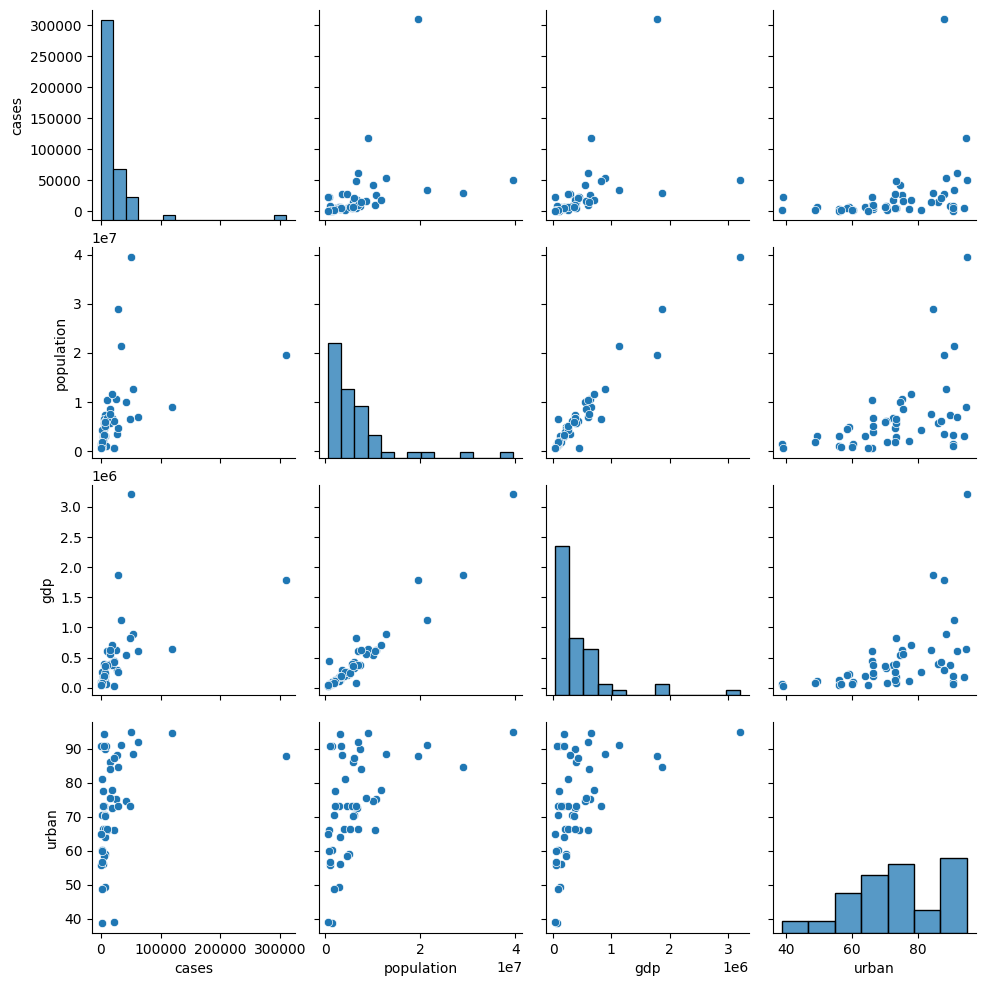

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

new_data_df = pd.DataFrame(new_data, columns=Data_1.columns)
sns.pairplot(new_data_df)
plt.show()

In [56]:
Data_2 = pd.DataFrame(new_data,index=Data_1.index,columns=Data_1.columns)  
Data_2.head(5)

,cases,population,gdp,urban
Alabama,7068.000000,4903185.0,2.307501e+05,59.04
Alaska,22240.291667,731545.0,4.372885e+05,66.02
Arizona,7648.000000,7278717.0,3.790188e+05,89.81
Arkansas,3281.000000,3017804.0,1.325964e+05,56.16
California,50470.000000,39512223.0,3.205000e+06,94.95


**The importance of imputation methods :** It is evident that the choice of imputation strategy significantly influences the final model performance and data distribution.

# _____________________________________________________________________________________

# 2.Data Cleaning & Integration:

**New database:**

Importing a secondary dataset and after, cleaning it, concatenating it with the current dataframe.

In [16]:
Data_3 = pd.read_csv('country.csv',header=1)
Data_3.head(5)

,1,CountryName,population,Population growth,CountryCode,cases,gdp
0,2,Brazil,207652865,0.82,BRA,835814,5.40E+11
1,2,Brazil,207652865,0.82,BRA,835814,5.40E+11
2,3,Switzerland,8372098,1.08,CHE,3951,6.50E+11
3,4,Germany,82667685,1.19,DEU,34890,4.20E+12
4,5,Denmark,?,0.83,DNK,4226,2500000000


In [17]:
Data_3.rename(index=Data_3['CountryName'],inplace=True)
Data_3.drop(columns=['1','CountryName'],inplace=True)
#Data_3.rename(columns={'population':'pop','Population growth':'pg','CountryCode':'cc','cases':'cases','gdp':'gdp'},inplace=True)
Data_3.head(5)

,population,Population growth,CountryCode,cases,gdp
Brazil,207652865,0.82,BRA,835814,5.40E+11
Brazil,207652865,0.82,BRA,835814,5.40E+11
Switzerland,8372098,1.08,CHE,3951,6.50E+11
Germany,82667685,1.19,DEU,34890,4.20E+12
Denmark,?,0.83,DNK,4226,2500000000


#  -------------------------

**2-1.Duplication:**

`duplicated()`, This step identifies **duplicate rows** rather than duplicate features. Using the `.duplicated()` method, we can flag rows that are identical to previously occurring ones. The `.duplicated().sum()` function is then applied to quantify the total number of duplicates in the dataset. **Finally,** the `.drop_duplicates()` method is employed to remove these redundant entries, ensuring data integrity.

**Step_7**: Execute this cell after completing Step 0. ❌Please note that you must first run at least one previous step (Step 1, 2, 3, 4, 5, or 6) before executing this cell to handle duplicates.❌

In [18]:
print(f'The Total Number Of Duplicated Sample Is :{Data_3.duplicated().sum()}')
print(Data_3.duplicated())

The Total Number Of Duplicated Sample Is :1
Brazil           False
Brazil            True
Switzerland      False
Germany          False
Denmark          False
Spain            False
France           False
Japan            False
Greece           False
Iran             False
Kuwait           False
Morocco          False
United Stated    False
Nigeria          False
Qatar            False
Sweden           False
India            False
World            False
dtype: bool


In [19]:
Data_3.drop_duplicates(inplace=True)
Data_3.head(6)     

,population,Population growth,CountryCode,cases,gdp
Brazil,207652865,0.82,BRA,835814,5.40E+11
Switzerland,8372098,1.08,CHE,3951,6.50E+11
Germany,82667685,1.19,DEU,34890,4.20E+12
Denmark,?,0.83,DNK,4226,2500000000
Spain,46443959,-0.01,ESP,50021,4.20E+12
France,66896109,0.41,FRA,54755,8.79E+11


#  -------------------------

**2-2.Concatenation:** 

`pd.concat([...])`, After concatenating the datasets, we observed that several columns contain a significant number of `NaN` values. Since there is no effective way to impute these values, **the most appropriate approach is to drop these entire columns.**

In [20]:
Data_4 = pd.concat([Data_2,Data_3])     # Data_4 = pd.concat([Data_2,Data_3],.❌ignore_index=True.❌)     

Data_4

,cases,population,gdp,urban,Population growth,CountryCode
Alabama,7068.0,4903185.0,230750.1,59.04,NaN,NaN
Alaska,10.0,731545.0,500000.0,66.02,NaN,NaN
Arizona,7648.0,7278717.0,379018.8,89.81,NaN,NaN
Arkansas,3281.0,3017804.0,132596.4,56.16,NaN,NaN
California,50470.0,39512223.0,3205000.1,94.95,NaN,NaN
...,...,...,...,...,...,...
Nigeria,91077,185989640,39800000,NaN,2.62,NGA
Qatar,11610,2569804,4.40E+11,NaN,3.5,QAT
Sweden,40731,9903122,5.90E+12,NaN,?,SWE
India,297319,1324171354,3.40E+11,NaN,1.15,IND


In [21]:
Data_4.dtypes

cases                 object
population            object
gdp                   object
urban                float64
Population growth        str
CountryCode              str
dtype: object

In [22]:
Data_4.drop(columns=['urban','Population growth','CountryCode'],inplace=True)
Data_4.head(5)

,cases,population,gdp
Alabama,7068.0,4903185.0,230750.1
Alaska,10.0,731545.0,500000.0
Arizona,7648.0,7278717.0,379018.8
Arkansas,3281.0,3017804.0,132596.4
California,50470.0,39512223.0,3205000.1


# _____________________________________________________________________________________

# 3.Advanced Data Analysis & Exploration:

"""

import pandas as pd
import io

# Creating the dataset as shown in the image
data = {
    'Name': ['Galaxy S10', 'Lumia 950', 'Xpreia 1 II', 'iphone13', 'U Ultra', 'Galaxy S8', 'iphone 11 pro max', 'Moto G5', ' Pixel'],
    'OS': ['Android', 'windows', 'Android', 'ios', 'Android', 'Android', 'ios', 'Android', ' Android'],
    'Capacity': [128, 32, 256, 128, 64, 16, 256, 16, 128],
    'Ram': [8, 3, 8, 2, 4, 2, 4, 3, 4],
    'Weight': [163.0, 150.0, 181.0, 138.0, 170.0, 145.0, 226.0, 144.5, 143.0],
    'Company': ['Samsung', 'Microsoft', ' Sony', 'Apple', 'HTC', 'Samsung', 'Apple', 'Motorola', 'Google'],
    'inch': [6.2, 5.2, 6.5, 4.7, 5.7, 5.1, 6.5, 5.0, 5.0]
}
df = pd.DataFrame(data)
print(df)

# Optional: Save to CSV for the user to download
df.to_csv(r'C:\Users\Administer\Desktop\smartphone.csv', index=False)

"""

In [23]:
Data_5 = pd.read_csv('smartphone.csv')
Data_5.head(5)

,Name,OS,Capacity,Ram,Weight,Company,inch
0,Galaxy S10,Android,128,8,163.0,Samsung,6.2
1,Lumia 950,windows,32,3,150.0,Microsoft,5.2
2,Xpreia 1 II,Android,256,8,181.0,Sony,6.5
3,iphone13,ios,128,2,138.0,Apple,4.7
4,U Ultra,Android,64,4,170.0,HTC,5.7


#  -------------------------

**3-1.Descriptive Statistics:**


To gain initial insights into the smartphone dataset, We implemented descriptive statistical analysis. This process includes:

**Central Tendency:** Calculating the mean and median to identify the average values of hardware specifications.

**Dispersion:** Analyzing the standard deviation, variance, and range to understand the diversity in smartphone models.

**Distribution Insights:** Utilizing quartiles (25%, 50%, 75%) to observe the data spread and detect potential outliers in features like Weight or Ram.

In [24]:
Data_5.describe()

,Capacity,Ram,Weight,inch
count,9.000000,9.000000,9.000000,9.000000
mean,113.777778,4.222222,162.277778,5.544444
std,93.104481,2.279132,27.833333,0.698411
min,16.000000,2.000000,138.000000,4.700000
25%,32.000000,3.000000,144.500000,5.000000
50%,128.000000,4.000000,150.000000,5.200000
75%,128.000000,4.000000,170.000000,6.200000
max,256.000000,8.000000,226.000000,6.500000


In [25]:
Data_5.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      9 non-null      str    
 1   OS        9 non-null      str    
 2   Capacity  9 non-null      int64  
 3   Ram       9 non-null      int64  
 4   Weight    9 non-null      float64
 5   Company   9 non-null      str    
 6   inch      9 non-null      float64
dtypes: float64(2), int64(2), str(3)
memory usage: 636.0 bytes


In [26]:
Data_5.dtypes

Name            str
OS              str
Capacity      int64
Ram           int64
Weight      float64
Company         str
inch        float64
dtype: object

**Data Preprocessing**
To ensure the dataset is ready for analysis, Converted numerical columns from object to float to enable mathematical operations and statistical analysis

**Example:**
```python
# Converting numerical columns from object to float
df['Capacity'] = df['Capacity'].astype(float)


#  -------------------------

**3-2.Crosstabulation:**

Categorical Relationship Analysis (Crosstabulation): Performed crosstabulation to identify patterns and dependencies between categorical variables. By constructing contingency tables, We were able to observe the cross-frequency of features, providing insights into the distribution of smartphone attributes across different manufacturers and operating systems.(by: `pd.crosstab`)

In [27]:
pd.crosstab(Data_5['OS'],Data_5['Company'])

Company,Apple,Google,HTC,Microsoft,Motorola,Samsung,Sony
OS,,,,,,,
Android,0,1,1,0,1,2,1
ios,2,0,0,0,0,0,0
windows,0,0,0,1,0,0,0


#  -------------------------

**3-3.Pivot Tables:**

Advanced Data Reshaping (Pivot Tables): Leveraged pivot tables to perform multi-dimensional data aggregation. By reshaping the dataset, I was able to transform raw data into summarized views, facilitating the analysis of trends and patterns across multiple dimensions (e.g., comparing average Ram or Capacity across different Company and OS combinations).

In [28]:
pd.pivot_table(Data_5,index='Name',columns='Company',values='Ram')

Company,Apple,Google,HTC,Microsoft,Motorola,Samsung,Sony
Name,,,,,,,
Galaxy S10,NaN,NaN,NaN,NaN,NaN,8.0,NaN
Galaxy S8,NaN,NaN,NaN,NaN,NaN,2.0,NaN
Lumia 950,NaN,NaN,NaN,3.0,NaN,NaN,NaN
Moto G5,NaN,NaN,NaN,NaN,3.0,NaN,NaN
Pixel,NaN,4.0,NaN,NaN,NaN,NaN,NaN
U Ultra,NaN,NaN,4.0,NaN,NaN,NaN,NaN
Xpreia 1 II,NaN,NaN,NaN,NaN,NaN,NaN,8.0
iphone 11 pro max,4.0,NaN,NaN,NaN,NaN,NaN,NaN
iphone13,2.0,NaN,NaN,NaN,NaN,NaN,NaN


#  -------------------------

**3-4.Grouping:**

Group-wise Analysis: Implemented grouping operations to execute a “split-apply-combine” strategy. By grouping the data based on categorical attributes, I was able to analyze the statistical distribution within each segment, providing deeper insights into how specific features behave across different categories.

❌❌To facilitate effective grouping and analysis, the 'OS' and 'Name' columns were removed. This ensures that only one categorical feature remains, preventing redundancy during the grouping process.❌❌

In [29]:
Data_5.drop(columns=['Name','OS'],inplace=True)   
Data_5.groupby(Data_5['Company']).mean()   

,Capacity,Ram,Weight,inch
Company,,,,
Apple,192.0,3.0,182.0,5.60
Google,128.0,4.0,143.0,5.00
HTC,64.0,4.0,170.0,5.70
Microsoft,32.0,3.0,150.0,5.20
Motorola,16.0,3.0,144.5,5.00
Samsung,72.0,5.0,154.0,5.65
Sony,256.0,8.0,181.0,6.50


#  -------------------------

**3-5.Correlation:**

Statistical Correlation Analysis: Computed a correlation matrix to quantify the linear relationships between numerical attributes. By analyzing the correlation coefficients, I identified strong positive or negative associations between features, which is essential for understanding feature dependencies and informing future modeling steps. 

❌❌Since the correlation coefficient is only defined for numerical variables, all non-numeric columns (such as ‘Name’, ‘OS’, and ‘Company’) were excluded from the analysis to ensure accurate computation of the correlation matrix.❌❌

**and visualized the results using a heatmap for easier interpretation.**

In [30]:
Data_5.drop(columns=['Company'],inplace=True)
Data_5

,Capacity,Ram,Weight,inch
0,128,8,163.0,6.2
1,32,3,150.0,5.2
2,256,8,181.0,6.5
3,128,2,138.0,4.7
4,64,4,170.0,5.7
5,16,2,145.0,5.1
6,256,4,226.0,6.5
7,16,3,144.5,5.0
8,128,4,143.0,5.0


In [31]:
Data_5.corr()

,Capacity,Ram,Weight,inch
Capacity,1.000000,0.572842,0.731434,0.727581
Ram,0.572842,1.000000,0.376255,0.778309
Weight,0.731434,0.376255,1.000000,0.855485
inch,0.727581,0.778309,0.855485,1.000000


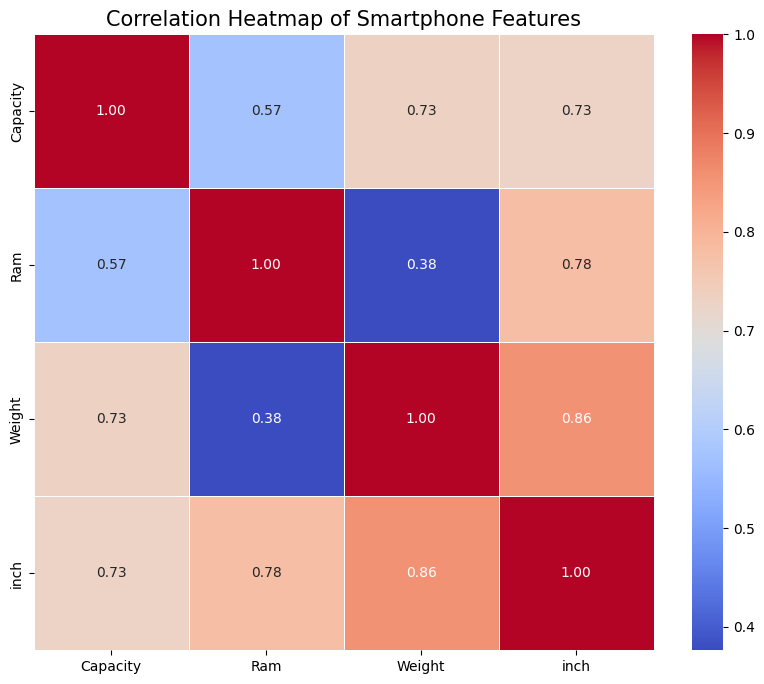

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data_5.drop(columns=['Name', 'OS', 'Company'], inplace=True)
corr_matrix = Data_5.corr()
plt.figure(figsize=(10, 8))

#---------------------------------------------------------------
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
# annot=True: اعداد داخل خانه‌ها را نمایش می‌دهد
# cmap='coolwarm': طیف رنگی از آبی (منفی) به قرمز (مثبت)
# fmt=".2f": نمایش اعداد با دو رقم اعشار
# linewidths: ایجاد فاصله کوچک بین خانه‌ها برای زیبایی بیشتر
# ۵. اضافه کردن عنوان
#---------------------------------------------------------------

plt.title('Correlation Heatmap of Smartphone Features', fontsize=15)
plt.show()

**The analysis reveals strong positive correlations between physical dimensions (inch, Weight) and performance specs (Ram, Capacity). Notably, screen size (inch) shows a very high correlation with both Weight (0.86) and Ram (0.78), suggesting that larger devices are typically heavier and more powerful**